In [7]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [9]:
df = pd.read_csv(DATA_PATH / "wrangled_data.csv", low_memory=False)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nDatasets:")
print(df["dataset"].value_counts())

Shape: 38,995 rows x 44 columns

Datasets:
dataset
HSE 2019        8201
HSE 2018        8177
HSE 2017        7996
HSE 2022        7727
DAPHNIE 2024    5237
DAPHNIE 2023    1657
Name: count, dtype: int64


## DAPHNIE vs HSE: Covariate Imbalance

### Rationale

The within-HSE comparison (notebook 01) established that the four HSE waves can be pooled
as a single target, with drift driven by employment and possibly a survey instrument change
in `smoke_ever`. Health outcomes are stable across the pre/post-2020 split.

We now turn to the main question: **how much do the DAPHNIE waves differ from HSE in their
covariate distributions?** This is the distributional shift we need to correct for in the
density ratio estimation.

We use a **2 × 2 comparison structure**:

| | HSE 2022 | HSE pre-2020 (2017–2019) |
|---|---|---|
| **DAPHNIE 2023** | contemporaneous | cross-period |
| **DAPHNIE 2024** | contemporaneous | cross-period |

The two HSE targets address a practical question: does the choice of reference period matter?
If the imbalance pattern is similar against both targets, pooling all HSE waves is safe.
If the patterns diverge, the reference period choice will affect the importance weights.

### SMD convention

$$\text{SMD} = \frac{\bar{x}_{\text{DAPHNIE}} - \bar{x}_{\text{HSE}}}
{\sqrt{(s^2_{\text{DAPHNIE}} + s^2_{\text{HSE}}) / 2}}$$

Positive SMD means DAPHNIE respondents score higher on that variable. DAPHNIE uses
`svy_wt`; HSE uses `wt_int`.

In [10]:
# age3cat excluded in favour of age7cat
EXCLUDE = {
    "dataset", "wt_int", "svy_wt", "SurveyWeight", "EQ_index",
    "util_rowen", "EQvas", "LSS", "LSS_rs", "age3cat",
}

analytic_cols = [
    c for c in df.columns
    if c not in EXCLUDE
    and pd.api.types.is_numeric_dtype(df[c])
]

print(f"Analytic columns ({len(analytic_cols)}):")
print(analytic_cols)

Analytic columns (34):
['Sex', 'eqv3', 'eqv5', 'MO5L', 'SC5L', 'UA5L', 'PD5L', 'AD5L', 'bmi_calc', 'bmi_cat', 'edu_cat', 'edu_pst', 'christian_bin', 'age7cat', 'srh', 'smoke_ever', 'smoke_ecig', 'alcohol_yr', 'diabetes', 'obese', 'resp', 'skin', 'sat', 'ill_dis', 'meds_num', 'eth4cat_Asian', 'eth4cat_Black', 'eth4cat_Others', 'eth4cat_White', 'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired', 'emp_cat_Student', 'emp_cat_Unemployed']


In [11]:
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    s, w = series[mask], weights[mask]
    return np.average(s, weights=w)


def weighted_var(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() < 2:
        return np.nan
    s, w = series[mask], weights[mask]
    mu = np.average(s, weights=w)
    return np.average((s - mu) ** 2, weights=w)


def compute_smd(source_series, source_weights, target_series, target_weights):
    """SMD = (source_mean - target_mean) / pooled SD."""
    mu_s = weighted_mean(source_series, source_weights)
    mu_t = weighted_mean(target_series, target_weights)
    if np.isnan(mu_s) or np.isnan(mu_t):
        return np.nan
    var_s = weighted_var(source_series, source_weights)
    var_t = weighted_var(target_series, target_weights)
    if np.isnan(var_s) or np.isnan(var_t):
        return np.nan
    pooled_sd = np.sqrt((var_s + var_t) / 2)
    if pooled_sd == 0:
        return np.nan
    return (mu_s - mu_t) / pooled_sd

In [12]:
pre_2020 = df[df["dataset"].isin(["HSE 2017", "HSE 2018", "HSE 2019"])]
hse_2022 = df[df["dataset"] == "HSE 2022"]
daphnie_2023 = df[df["dataset"] == "DAPHNIE 2023"]
daphnie_2024 = df[df["dataset"] == "DAPHNIE 2024"]

comparisons = {
    "D2023 vs HSE2022":   (daphnie_2023, "svy_wt", hse_2022,  "wt_int"),
    "D2024 vs HSE2022":   (daphnie_2024, "svy_wt", hse_2022,  "wt_int"),
    "D2023 vs pre-2020":  (daphnie_2023, "svy_wt", pre_2020,  "wt_int"),
    "D2024 vs pre-2020":  (daphnie_2024, "svy_wt", pre_2020,  "wt_int"),
}

smd_results = {}
for label, (src, src_wt_col, tgt, tgt_wt_col) in comparisons.items():
    src_wt = src[src_wt_col].fillna(1.0)
    tgt_wt = tgt[tgt_wt_col].fillna(1.0)
    smd_results[label] = {
        col: compute_smd(src[col], src_wt, tgt[col], tgt_wt)
        for col in analytic_cols
    }

smd_df = pd.DataFrame(smd_results).rename_axis("variable")

print("SMD table (DAPHNIE − HSE; positive = DAPHNIE higher):")
display(smd_df.sort_values("D2023 vs HSE2022", key=abs, ascending=False).round(3))

SMD table (DAPHNIE − HSE; positive = DAPHNIE higher):


,D2023 vs HSE2022,D2024 vs HSE2022,D2023 vs pre-2020,D2024 vs pre-2020
variable,,,,
bmi_calc,-2.742,NaN,-2.754,NaN
bmi_cat,-2.056,NaN,-2.066,NaN
srh,-0.744,-0.807,-0.754,-0.816
emp_cat_Retired,-0.518,-0.025,-0.521,-0.028
emp_cat_Employed,0.415,-0.100,0.429,-0.086
smoke_ever,-0.330,0.181,-0.511,0.005
eth4cat_White,-0.286,-0.138,-0.314,-0.166
smoke_ecig,-0.268,0.043,-0.251,0.060
ill_dis,-0.255,-0.127,-0.281,-0.153


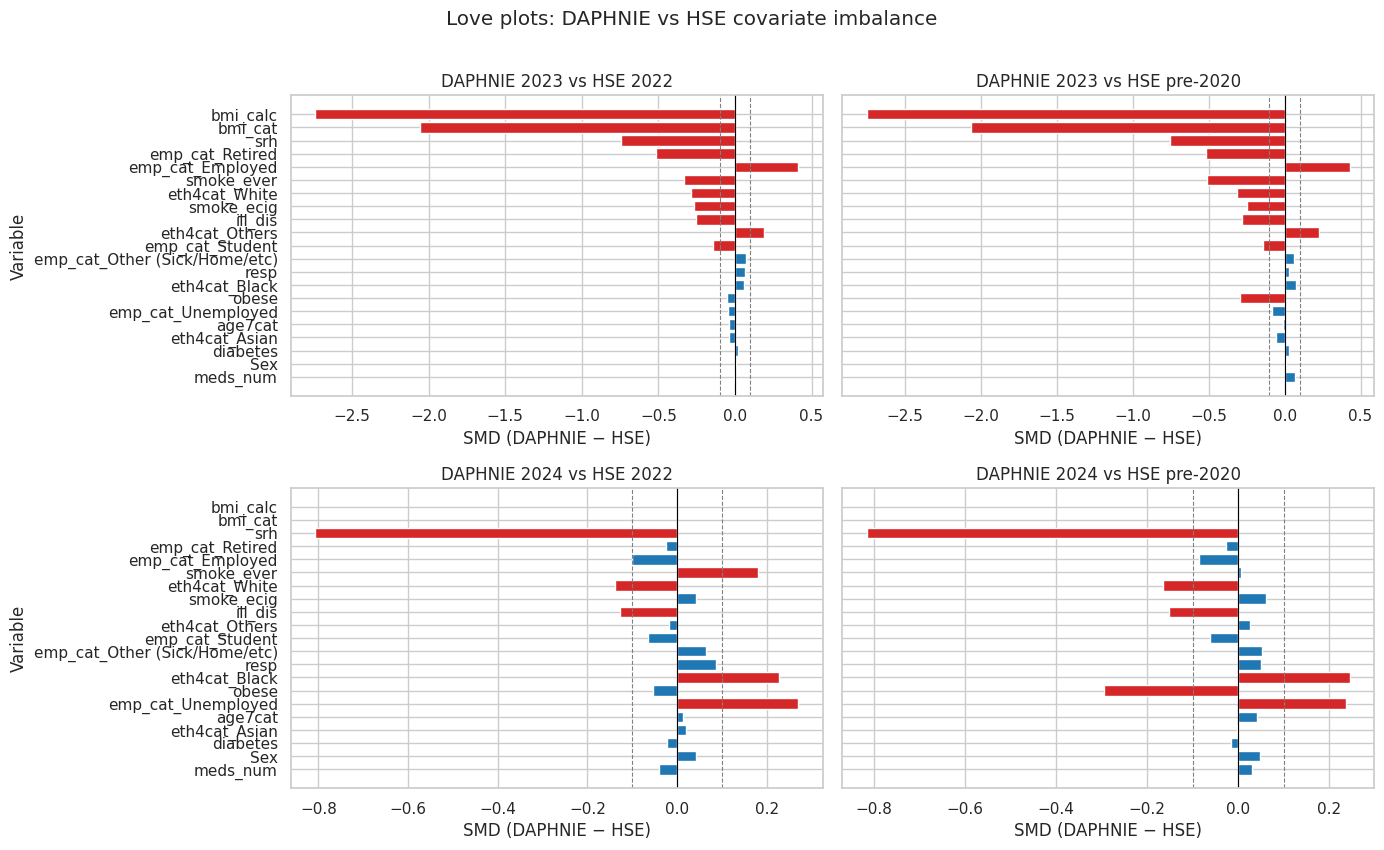

In [13]:
# 2x2 Love plot: rows = DAPHNIE wave, columns = HSE target
# Variable order fixed by |SMD| in D2023 vs HSE2022 for consistent reading across panels
order = (
    smd_df["D2023 vs HSE2022"].dropna()
    .abs().sort_values()
    .index.tolist()
)

panel_layout = [
    ("D2023 vs HSE2022",  "DAPHNIE 2023 vs HSE 2022"),
    ("D2023 vs pre-2020", "DAPHNIE 2023 vs HSE pre-2020"),
    ("D2024 vs HSE2022",  "DAPHNIE 2024 vs HSE 2022"),
    ("D2024 vs pre-2020", "DAPHNIE 2024 vs HSE pre-2020"),
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, max(6, len(order) * 0.4)),
    sharey=True, sharex=False,
)

for ax, (col_key, title) in zip(axes.flat, panel_layout):
    smds = smd_df[col_key].reindex(order).dropna()
    colors = ["#d62728" if abs(v) > 0.1 else "#1f77b4" for v in smds]
    ax.barh(smds.index, smds.values, color=colors)
    ax.axvline(0,    color="black", linewidth=0.8)
    ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
    ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("SMD (DAPHNIE − HSE)")

axes[0, 0].set_ylabel("Variable")
axes[1, 0].set_ylabel("Variable")

fig.suptitle("Love plots: DAPHNIE vs HSE covariate imbalance", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "love_plot_daphnie_vs_hse.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Variables imbalanced (|SMD| > 0.1) in at least one comparison
imbalanced = (
    smd_df[smd_df.abs().gt(0.1).any(axis=1)]
    .sort_values("D2023 vs HSE2022", key=abs, ascending=False)
)

print(f"Variables with |SMD| > 0.1 in at least one comparison: {len(imbalanced)}")
display(imbalanced.round(3))

Variables with |SMD| > 0.1 in at least one comparison: 23


,D2023 vs HSE2022,D2024 vs HSE2022,D2023 vs pre-2020,D2024 vs pre-2020
variable,,,,
bmi_calc,-2.742,NaN,-2.754,NaN
bmi_cat,-2.056,NaN,-2.066,NaN
srh,-0.744,-0.807,-0.754,-0.816
emp_cat_Retired,-0.518,-0.025,-0.521,-0.028
emp_cat_Employed,0.415,-0.100,0.429,-0.086
smoke_ever,-0.330,0.181,-0.511,0.005
eth4cat_White,-0.286,-0.138,-0.314,-0.166
smoke_ecig,-0.268,0.043,-0.251,0.060
ill_dis,-0.255,-0.127,-0.281,-0.153
